In [1]:
from Scripts.Random_forest_nested import *
import matplotlib.pyplot as plt
import pickle 
from scipy.stats import randint
import seaborn as sns
import pandas as pd
import numpy as np
import shap

In [2]:
df = pd.read_excel('../Data_preprocessing/all_time.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox','scaled_no2','scaled_formaldehyd','scaled_acetone','scaled_acetald',
    'scaled_bc', 'scaled_PM25','no2_street', 'nox_street', 'pm25_street', 'gestational_age', 'lrti_1y',
       'genetic_risk_score_asthma']],df.verificeret_12y

In [3]:
list_parameters=[r'$\mathbf{NO_x}$',r'$\mathbf{NO_2}$',"Formaldehyd","Acetone","Acetald","Black Carbon",r'$\mathbf{PM_{2.5}}$',r"$\mathbf{Street \ NO_2}$",r"$\mathbf{Street \ NO_x}$",r"$\mathbf{Street \ PM_{2.5}}$","Gestational age","PRS",'LRTI']

In [4]:
replace_dict=dict(zip(X.columns,list_parameters))
X=X.rename(columns=replace_dict)

In [5]:
replace_dict

{'scaled_nox': '$\\mathbf{NO_x}$',
 'scaled_no2': '$\\mathbf{NO_2}$',
 'scaled_formaldehyd': 'Formaldehyd',
 'scaled_acetone': 'Acetone',
 'scaled_acetald': 'Acetald',
 'scaled_bc': 'Black Carbon',
 'scaled_PM25': '$\\mathbf{PM_{2.5}}$',
 'no2_street': '$\\mathbf{Street \\ NO_2}$',
 'nox_street': '$\\mathbf{Street \\ NO_x}$',
 'pm25_street': '$\\mathbf{Street \\ PM_{2.5}}$',
 'gestational_age': 'Gestational age',
 'lrti_1y': 'PRS',
 'genetic_risk_score_asthma': 'LRTI'}

In [6]:
param_distributions = {
    'n_estimators':           [300],
    'max_depth':              randint(2, 6),
    'min_samples_leaf':       randint(5, 15),
    'max_features':           [0.5, 0.6, 0.7],
    'max_samples':            [0.5, 0.6, 0.7],
    # class_weight removed
}
dataframe=nested_cv_calibrated_rf(
    X, y,
    n_repeats=5,
    n_splits=5,
    n_neighbors_imputer=25,
    param_distributions=param_distributions)

fold   1/25  test AUC=0.662  BSS=+0.052  ICI=0.028   | apparent AUC=0.875
fold   2/25  test AUC=0.569  BSS=+0.021  ICI=0.033   | apparent AUC=0.903
fold   3/25  test AUC=0.693  BSS=+0.068  ICI=0.052   | apparent AUC=0.920
fold   4/25  test AUC=0.665  BSS=+0.022  ICI=0.040   | apparent AUC=0.811
fold   5/25  test AUC=0.711  BSS=+0.023  ICI=0.075   | apparent AUC=0.952
fold   6/25  test AUC=0.613  BSS=+0.035  ICI=0.022   | apparent AUC=0.909
fold   7/25  test AUC=0.579  BSS=-0.011  ICI=0.025   | apparent AUC=0.827
fold   8/25  test AUC=0.661  BSS=+0.046  ICI=0.022   | apparent AUC=0.927
fold   9/25  test AUC=0.615  BSS=+0.050  ICI=0.052   | apparent AUC=0.861
fold  10/25  test AUC=0.658  BSS=+0.018  ICI=0.042   | apparent AUC=0.893
fold  11/25  test AUC=0.571  BSS=-0.008  ICI=0.047   | apparent AUC=0.972
fold  12/25  test AUC=0.536  BSS=-0.001  ICI=0.057   | apparent AUC=0.905
fold  13/25  test AUC=0.668  BSS=+0.053  ICI=0.027   | apparent AUC=0.900
fold  14/25  test AUC=0.715  BSS=+0.03

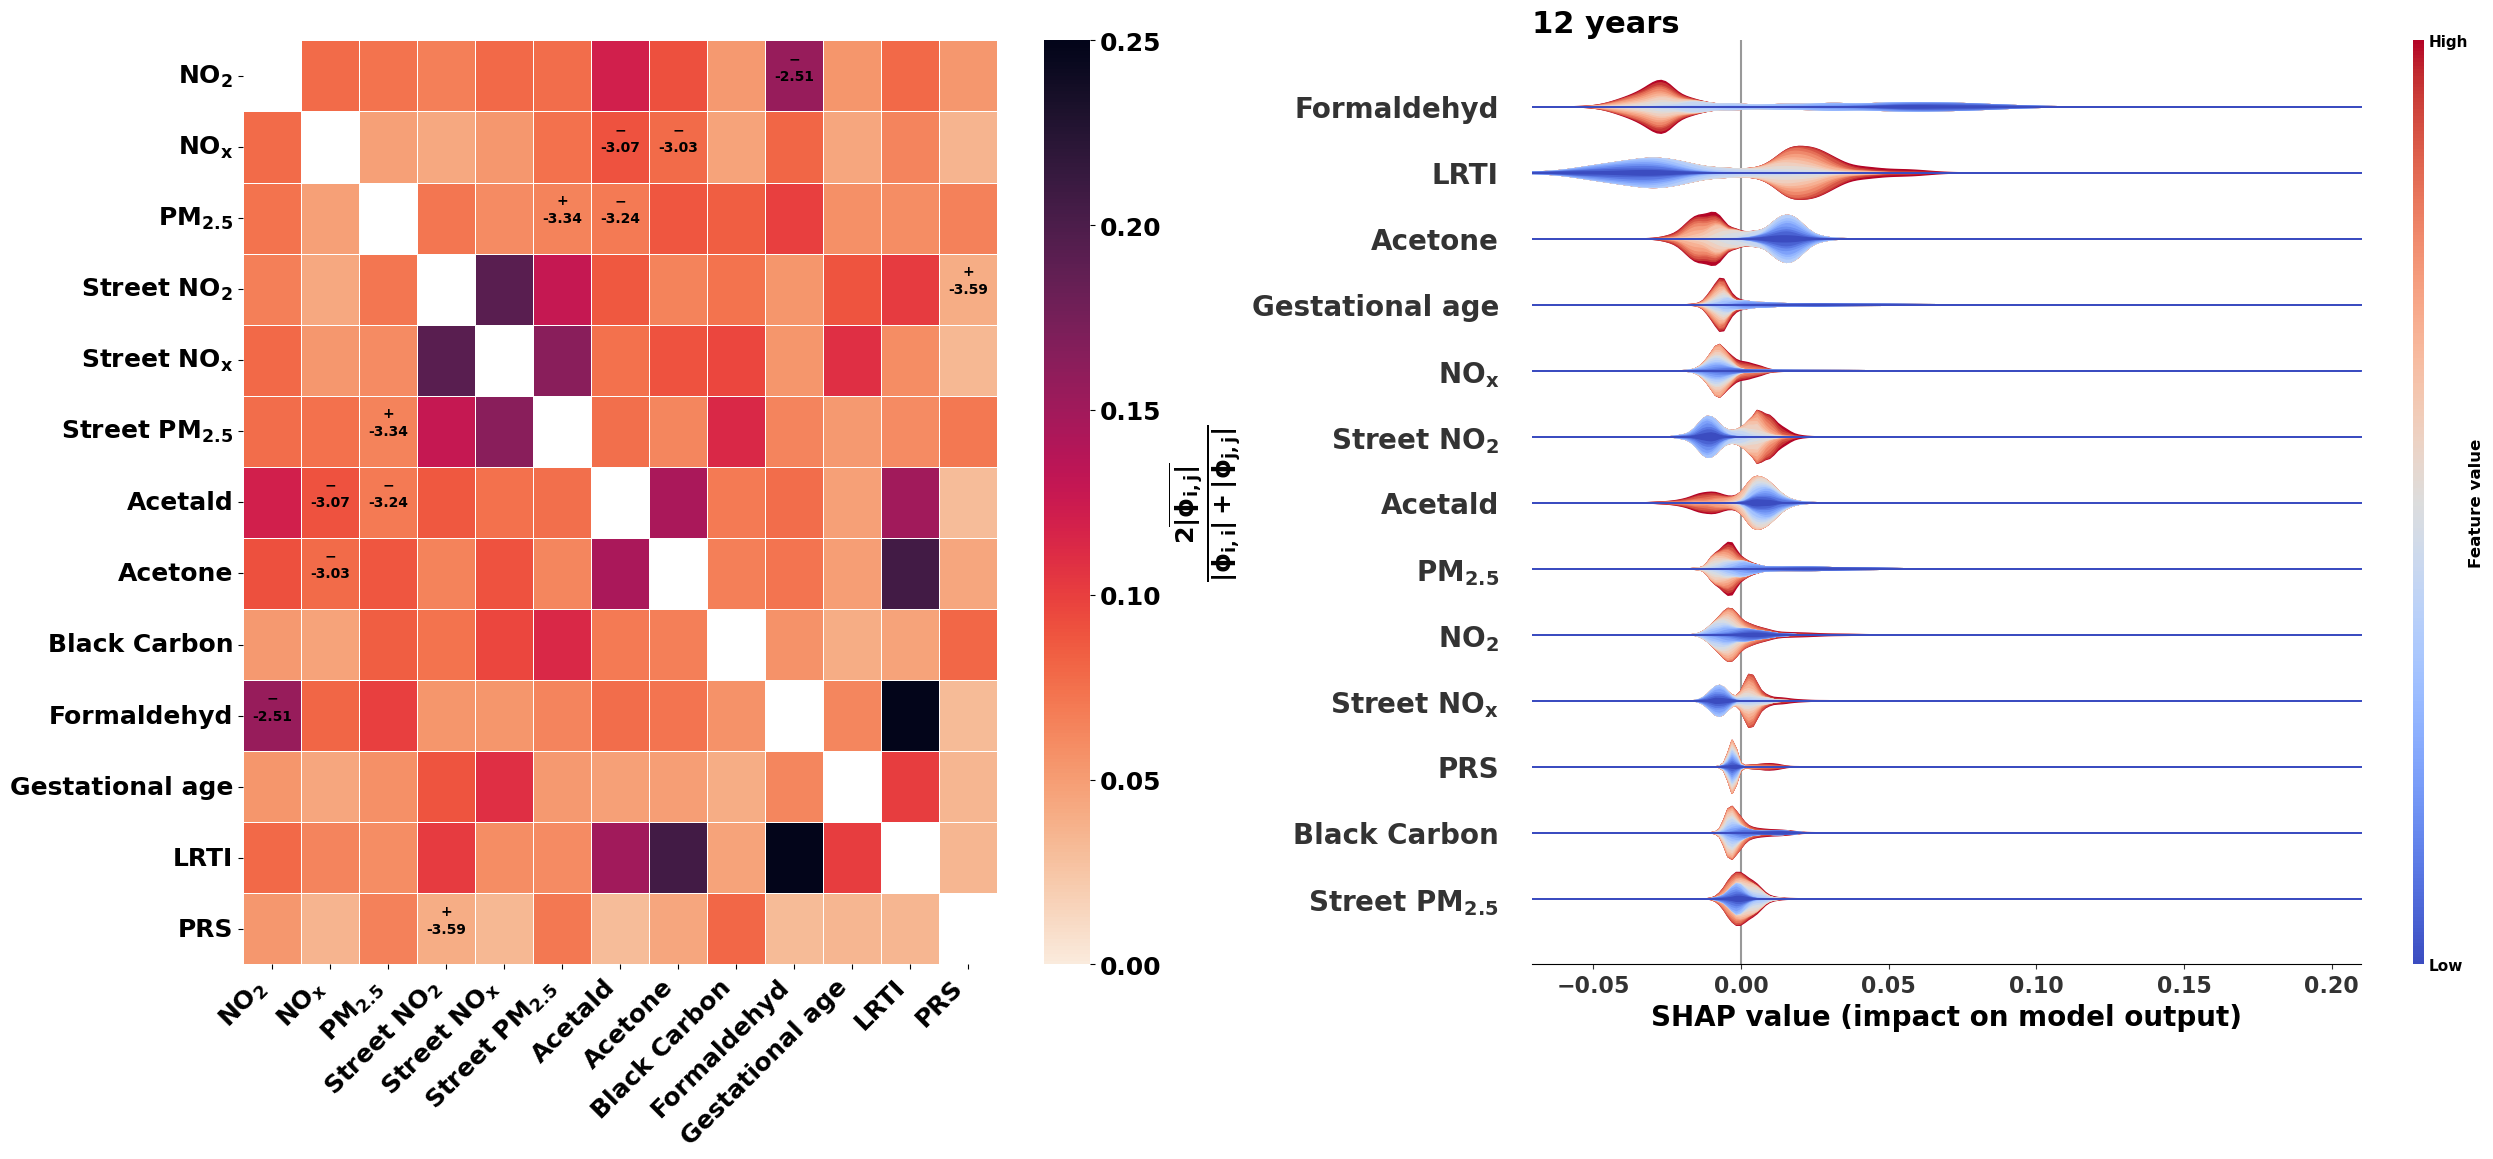

In [8]:

# Swap the columns to create the reverse relationships (B->A, C->A, C->B)
df_flipped = dataframe["interaction_stats"].rename(columns={'feature_i': 'feature_j', 'feature_j': 'feature_i'})

# Combine them together
df_full = pd.concat([dataframe["interaction_stats"], df_flipped]).drop_duplicates()
features_to_drop = ["feature_i", "feature_j"]

matrix_r = df_full.pivot(index='feature_i', columns='feature_j', values='R_mean').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_con = df_full.pivot(index='feature_i', columns='feature_j', values='sign_consistency').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect = df_full.pivot(index='feature_i', columns='feature_j', values='abs_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect_sign = df_full.pivot(index='feature_i', columns='feature_j', values='signed_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
dominant_sign= df_full.pivot(index='feature_i', columns='feature_j', values='dominant_sign').rename_axis(None, axis=0).rename_axis(None, axis=1)
plt.rcParams.update({
    "mathtext.default":  "bf",
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "figure.titleweight":"bold",
})
corr_matrix=X.corr(method="spearman")
k = matrix_r.shape[0]

fig = plt.figure(figsize=(30, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.35)
ax0, ax1 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

hm = sns.heatmap(matrix_r, cmap="rocket_r", vmin=0, vmax=0.25,
                 linewidths=0.4, linecolor="white", ax=ax0,
                 cbar_kws={'label': r'$\frac{2\overline{|\phi_{i,j}|}}{|\phi_{i,i}|+|\phi_{j,j}|}$'})

norm, cmap = hm.collections[0].norm, hm.collections[0].cmap
for i in range(k):
    for j in range(k):                            # lower triangle only
        if matrix_con.iloc[i, j] < 0.8:
            continue
        if i==j:
            continue
        if np.abs(corr_matrix.loc[matrix_con.columns[i],matrix_con.columns[j]])>0.3:
            continue   
        val = matrix_effect.iloc[i, j]
        sgn = "+" if dominant_sign.iloc[i, j] >= 0 else "\u2212"
        r, g, b, _ = cmap(norm(matrix_r.iloc[i, j]))
        ax0.text(j + 0.5, i + 0.5, f"{np.log10(val):.2f}", ha="center", va="center",  fontsize=10, fontweight="bold")
        ax0.text(j + 0.5, i + 0.25, f"{sgn}", ha="center", va="center",
                 fontsize=10, fontweight="bold")      

# ---- heatmap ticks ----
ax0.tick_params(axis="both", labelsize=18)
plt.setp(ax0.get_xticklabels(), rotation=45, ha="right", fontsize=18, fontweight="bold")
plt.setp(ax0.get_yticklabels(), fontsize=18, fontweight="bold")

# ---- colorbar ----
cbar = hm.collections[0].colorbar
cbar.ax.yaxis.label.set(size=26, weight="bold")
cbar.ax.tick_params(labelsize=18)
plt.setp(cbar.ax.get_yticklabels(), fontweight="bold")

# ---- shap panel ----
plt.sca(ax1)
shap.plots.violin(dataframe["shap_explanation"],
                  plot_type="layered_violin",
                  max_display=15, show=False, plot_size=None)
ax1.tick_params(axis="y", labelsize=20)
ax1.tick_params(axis="x", labelsize=16)
plt.setp(ax1.get_yticklabels(), fontsize=20, fontweight="bold")
plt.setp(ax1.get_xticklabels(), fontsize=16, fontweight="bold")
ax1.set_xlabel(ax1.get_xlabel(), fontsize=20, fontweight="bold")
ax1.set_title("12 years", loc="left", fontsize=22, pad=6, fontweight="bold")

fig.savefig("../Plots/shap_12.png", bbox_inches="tight",dpi=300)  

In [11]:
with open("../Performence/results_rf_12y.pkl", "wb") as f:
    pickle.dump(dataframe, f)